In [48]:
import sys
import os
from pathlib import Path
import pprint
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

sys.path.append("../../_src/_001_aux_functions")
sys.path.append("../../_src/_002_readdata")
sys.path.append("../../_src/_003_ml_f")
#sys.path.append("../")

from functions_evaluation import nse
from functions_training import nse_basin_averaged
from utils import Optimizer, set_random_seed, upload_to_device, write_report
from camelsh import camelsh
from mflstm import MFLSTM

In [49]:
data_path = Path("C:/Users/mfjakows/Datasets/Headwater_CAMELSH").resolve()
train_entity_path = Path("../Input/headwater_training.txt").resolve()
test_entity_path = Path("../Input/headwater_testing.txt").resolve()
path_save_folder = Path("save_folder/").resolve()

In [ ]:
dynamic_input = {
    "1D": ["MAP"],
    #"1h": ["CAPE", "CRainf_frac", "LWdown", "PotEvap", "PSurf", "Qair", "Rainf", "SWdown", "Tair", "Wind_E", "Wind_N"],
    "1h": ["MAP"],
}
target = ["Q_camelsh_obs_norm"]
forcing = ["nldas_hourly"]

#static_input = [
    #"p_mean", "pet_mean", "aridity_index", "p_seasonality", "frac_snow",
    #"high_prec_freq", "high_prec_dur", "low_prec_freq", "low_prec_dur",
    #"ele_mt_sav", "slp_dg_uav", "ria_ha_usu", "run_mm_syr", "gwt_cm_sav",
    #"cly_pc_uav", "slt_pc_uav", "snd_pc_uav", "kar_pc_use", "prm_pc_use",
    #"pac_pc_use", "crp_pc_use", "for_pc_use", "urb_pc_use", "DRAIN_SQKM"
#]
#static_input = [
    #"DRAIN_SQKM"
#]
static_input = [
    "runoffcat_aw","wetindexcat_aw","waterinputcat_aw", "sw_fluxcat_aw",
    "pctdecid2010cat_aw", "pctconif2010cat_aw", "pctcrop2010cat_aw",
    "pctgrs2010cat_aw", "pcturblo2010cat_aw", "pcturbhi2010cat_aw",
    "pctwdwet2010cat_aw", "pctow2010cat_aw",
    "sandcat_aw", "claycat_aw", "omcat_aw", "elevcat_aw", "rockncat_aw",  # ← comma added
    "DRAIN_SQKM"
]

#training_period = ["1987-01-01 00:00:00", "2009-12-31 23:00:00"]
#validation_period = ["2010-01-01 00:00:00", "2015-12-31 23:00:00"]
#testing_period = ["2016-01-01 00:00:00", "2022-12-31 23:00:00"]

training_period = ["2001-01-01 00:00:00", "2018-12-31 23:00:00"]
validation_period = ["2019-01-01 00:00:00", "2021-12-31 23:00:00"]
testing_period = ["2022-01-01 00:00:00", "2026-12-31 23:00:00"]

lookback_window = 0
forecast_interval = 6
SMOKE_TEST = True
model_configuration = {
    "n_dynamic_channels_lstm": 10,
    "no_of_layers": 1,
    "seq_length": 365 * 24,
    "custom_freq_processing": {
        "1D": {"n_steps": 351, "freq_factor": 24},
        "1h": {"n_steps": (365 - 351) * 24, "freq_factor": 1},
    },
    "predict_last_n": forecast_interval,
    #"predict_last_n": (24*14 + (365-14) - 1),
    "forecast_horizon": forecast_interval,
    "unique_prediction_blocks": True,
    "dynamic_embeddings": True,
    "hidden_size": 32 if SMOKE_TEST else 128,
    "batch_size_training": 16 if SMOKE_TEST else 128,
    "batch_size_evaluation": 128 if SMOKE_TEST else 1024,
    "no_of_epochs": 25 if SMOKE_TEST else 30,
    "dropout_rate": 0.4,
    "learning_rate": {1: 5e-4, 10: 1e-4, 25: 1e-5},
    "set_forget_gate": 3,
    "validate_every": 1 if SMOKE_TEST else 4,
    "validate_n_random_basins": 1 if SMOKE_TEST else -1,
}

modelclass = MFLSTM

seed = 110
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

In [51]:
train_dataset = camelsh(
    dynamic_input=dynamic_input,
    target=target,
    forcing=forcing,
    sequence_length=model_configuration["seq_length"],
    time_period=training_period,
    path_data=str(data_path),
    path_entities=str(train_entity_path),
    check_NaN=True,
    predict_last_n=model_configuration["predict_last_n"],
    static_input=static_input,
    custom_freq_processing=model_configuration["custom_freq_processing"],
    dynamic_embedding=model_configuration["dynamic_embeddings"],
    unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
    lookback_window=lookback_window,
    forecast_horizon=model_configuration["forecast_horizon"]
)

validation_dataset = camelsh(
    dynamic_input=dynamic_input,
    target=target,
    forcing=forcing,
    sequence_length=model_configuration["seq_length"],
    time_period=validation_period,
    path_data=str(data_path),
    path_entities=str(train_entity_path),
    check_NaN=True,
    predict_last_n=model_configuration["predict_last_n"],
    static_input=static_input,
    custom_freq_processing=model_configuration["custom_freq_processing"],
    dynamic_embedding=model_configuration["dynamic_embeddings"],
    unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
    lookback_window=lookback_window,
    forecast_horizon=model_configuration["forecast_horizon"]
)

test_dataset = camelsh(
    dynamic_input=dynamic_input,
    target=target,
    forcing=forcing,
    sequence_length=model_configuration["seq_length"],
    time_period=testing_period,
    path_data=str(data_path),
    path_entities=str(test_entity_path),
    check_NaN=True,
    predict_last_n=model_configuration["predict_last_n"],
    static_input=static_input,
    custom_freq_processing=model_configuration["custom_freq_processing"],
    dynamic_embedding=model_configuration["dynamic_embeddings"],
    unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
    lookback_window=lookback_window,
    forecast_horizon=model_configuration["forecast_horizon"]
)

print(f"Len Train Dataset {len(train_dataset)}")

# Basin diagnostic - shows which basins were dropped and why
requested = set(train_dataset.entities_ids)
loaded = set(train_dataset.sequence_data.keys())
dropped = requested - loaded
print(f"Requested: {len(requested)} basins | Loaded: {len(loaded)} | Dropped: {len(dropped)}")
if dropped:
    print(f"Dropped basins: {dropped}")

# Show which static columns have NaN per basin
nan_report = train_dataset.df_attributes.isnull().any(axis=1)
if nan_report.any():
    print("\nBasins with NaN in static attributes:")
    for basin_id in nan_report[nan_report].index:
        bad_cols = train_dataset.df_attributes.loc[basin_id].isnull()
        print(f"  {basin_id}: {list(bad_cols[bad_cols].index)}")
else:
    print("All static attributes present for all basins.")

Len Train Dataset 104663
Requested: 5 basins | Loaded: 5 | Dropped: 0
All static attributes present for all basins.


In [52]:


model_configuration["dynamic_input_size"] = {key : len(value) for key, value in dynamic_input.items()}
# Use actual loaded static count (some requested columns may not exist in attribute files)
actual_static_count = train_dataset.df_attributes.shape[1]
print(f"Actual static count: {actual_static_count}")
model_configuration["input_size_lstm"] = model_configuration["n_dynamic_channels_lstm"] + actual_static_count
#model_configuration["input_size_lstm"] = model_configuration["n_dynamic_channels_lstm"] + len(static_input)
device = "cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

train_dataset.calculate_basin_std()
train_dataset.calculate_global_statistics()
scaler = train_dataset.scaler
train_dataset.standardize_data()
validation_dataset.scaler = scaler
validation_dataset.standardize_data(standardize_output=False)
validation_dataset = {"validation" : validation_dataset}

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size = model_configuration["batch_size_training"],
    shuffle=True,
    drop_last=True,
    collate_fn=train_dataset.collate_fn
)
print("Number of batches in training:", len(train_loader))


sample = next(iter(train_loader))
#for key, value in sample.items():
    #if hasattr(value, "shape"):
        #print(key, value.shape)
    #else:
        #print(key, type(value))
        
set_random_seed(seed)
model = modelclass(model_configuration=model_configuration).to(device)
optimizer = Optimizer(model=model, model_configuration=model_configuration)
model.lstm.bias_hh_l0.data[model_configuration["hidden_size"]:2 * model_configuration["hidden_size"]] = model_configuration["set_forget_gate"]

sample_device = upload_to_device(sample, device)
with torch.no_grad():
    pred = model(sample_device)
print("Prediction shape:", pred["y_sim"].shape)

Actual static count: 10
Number of batches in training: 6541
Prediction shape: torch.Size([16, 6, 1])


In [53]:

if True:
    model.train()
    epoch_start_time = time.time()
    total_loss = []
    for idx, sample in enumerate(train_loader):
        sample = upload_to_device(sample, device)
        optimizer.optimizer.zero_grad()
        pred = model(sample)
        loss = nse_basin_averaged(
            y_sim=pred["y_sim"],
            y_obs=sample["y_obs"],
            per_basin_target_std=sample["basin_std"],
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.optimizer.step()
        total_loss.append(loss.item())
        if SMOKE_TEST and idx >= 2:
            break
    print(f"Smoke training loss: {np.mean(total_loss):.3f}; time: {time.time() - epoch_start_time:.1f}s")
else:
    print("Skipping training smoke test")

Smoke training loss: 0.010; time: 0.1s


In [54]:
#print(list(dataset.df_attributes.columns))
#s = dataset[0]
RUN_VALIDATION_STEP = True
#RUN_VALIDATION_STEP = False

if RUN_VALIDATION_STEP and not validation_dataset:
    raise RuntimeError("RUN_VALIDATION_STEP is True, but validation_dataset is empty. Run the validation dataset cell first.")

training_time = time.time()
best_validation = -np.inf
best_epoch = None

# Track per-epoch metrics for plotting
history_train_loss = []
history_val_nse = []
history_val_epochs = []

for epoch in range(1, model_configuration["no_of_epochs"] + 1):
    epoch_start_time = time.time()
    total_loss = []
    model.train()

    for idx, sample in enumerate(train_loader, start=1):
        sample = upload_to_device(sample, device)
        optimizer.optimizer.zero_grad()
        pred = model(sample)
        loss = nse_basin_averaged(
            y_sim=pred["y_sim"],
            y_obs=sample["y_obs"],
            per_basin_target_std=sample["basin_std"],
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.optimizer.step()
        total_loss.append(loss.item())

    epoch_loss = np.mean(total_loss)
    history_train_loss.append((epoch, epoch_loss))
    report = f'Epoch: {epoch:<2} | Loss training: {epoch_loss:.3f}'

    if RUN_VALIDATION_STEP and epoch % model_configuration["validate_every"] == 0:
        model.eval()
        validation_results = {}
        with torch.no_grad():
            for basin, dataset in validation_dataset.items():
                loader = DataLoader(
                    dataset=dataset,
                    batch_size=model_configuration["batch_size_evaluation"],
                    shuffle=False,
                    drop_last=False,
                    collate_fn=dataset.collate_fn,
                )
                frames = []
                for sample in loader:
                    sample = upload_to_device(sample, device)
                    pred = model(sample)
                    y_sim = pred["y_sim"] * dataset.scaler["y_std"].to(device) + dataset.scaler["y_mean"].to(device)
                    frames.append(pd.DataFrame({
                        "y_obs": sample["y_obs"].flatten().cpu().detach(),
                        "y_sim": y_sim[:, -model_configuration["predict_last_n"]:, :].flatten().cpu().detach(),
                    }, index=pd.to_datetime(sample["date"].flatten())))
                validation_results[basin] = pd.concat(frames, axis=0) if frames else pd.DataFrame(columns=["y_obs", "y_sim"])

        loss_validation = nse(df_results=validation_results)
        history_val_nse.append(loss_validation)
        history_val_epochs.append(epoch)
        report += f' | NSE validation: {loss_validation:.3f}'
        if loss_validation > best_validation:
            best_validation = loss_validation
            best_epoch = epoch
            torch.save(model.state_dict(), path_save_folder / "best_epoch_smoke.pt")

    report += f' | Epoch time: {time.time() - epoch_start_time:.1f}s | LR: {optimizer.optimizer.param_groups[0]["lr"]:.5f}'
    print(report)
    write_report(file_path=str(path_save_folder / "run_progress.txt"), text=report)
    optimizer.update_optimizer_lr(epoch=epoch)

print(f"Total training time: {time.time() - training_time:.1f}s")
if best_epoch is not None:
    print(f"Best validation NSE: {best_validation:.3f} at epoch {best_epoch}")

# Save one final model named by epoch count and forecast horizon
models_dir = Path("Models").resolve()
models_dir.mkdir(parents=True, exist_ok=True)
final_model_path = models_dir / f"model_ep{model_configuration['no_of_epochs']}_h{model_configuration['forecast_horizon']}.pt"
torch.save(model.state_dict(), final_model_path)
print(f"Model saved to: {final_model_path}")


Epoch: 1  | Loss training: 0.013 | NSE validation: 0.416 | Epoch time: 74.8s | LR: 0.00050
Epoch: 2  | Loss training: 0.011 | NSE validation: 0.456 | Epoch time: 66.4s | LR: 0.00050
Epoch: 3  | Loss training: 0.011 | NSE validation: 0.480 | Epoch time: 68.4s | LR: 0.00050
Epoch: 4  | Loss training: 0.010 | NSE validation: 0.506 | Epoch time: 69.0s | LR: 0.00050
Epoch: 5  | Loss training: 0.010 | NSE validation: 0.539 | Epoch time: 71.7s | LR: 0.00050
Epoch: 6  | Loss training: 0.009 | NSE validation: 0.539 | Epoch time: 75.9s | LR: 0.00050
Epoch: 7  | Loss training: 0.008 | NSE validation: 0.542 | Epoch time: 70.7s | LR: 0.00050
Epoch: 8  | Loss training: 0.008 | NSE validation: 0.594 | Epoch time: 84.5s | LR: 0.00050
Epoch: 9  | Loss training: 0.008 | NSE validation: 0.599 | Epoch time: 70.3s | LR: 0.00050
Epoch: 10 | Loss training: 0.007 | NSE validation: 0.620 | Epoch time: 69.1s | LR: 0.00050
Epoch: 11 | Loss training: 0.007 | NSE validation: 0.634 | Epoch time: 69.1s | LR: 0.00010

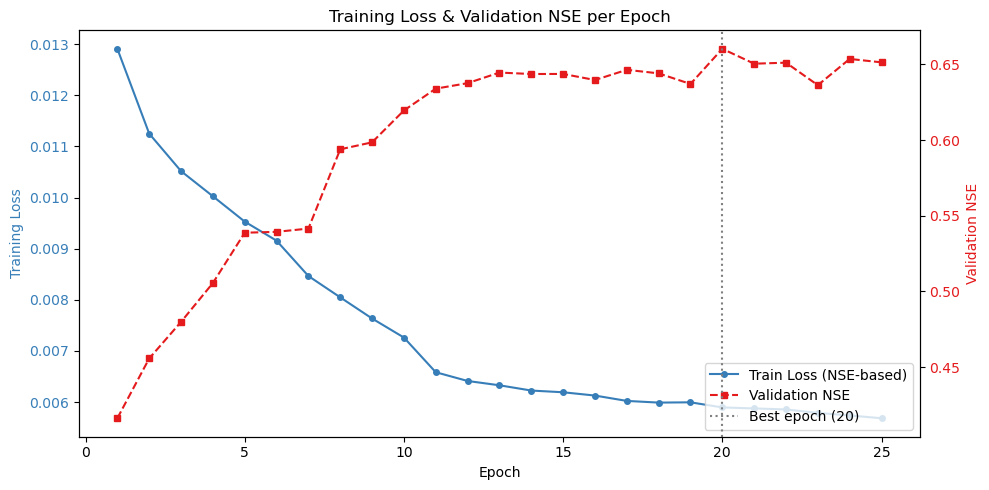

In [55]:
import matplotlib.pyplot as plt

epochs_loss, losses = zip(*history_train_loss)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(epochs_loss, losses, color="#377eb8", marker="o", markersize=4, label="Train Loss (NSE-based)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color="#377eb8")
ax1.tick_params(axis="y", labelcolor="#377eb8")

if history_val_nse:
    ax2 = ax1.twinx()
    ax2.plot(history_val_epochs, history_val_nse, color="#e41a1c", marker="s", markersize=5,
             linestyle="--", label="Validation NSE")
    if best_epoch is not None:
        ax2.axvline(x=best_epoch, color="grey", linestyle=":", linewidth=1.5, label=f"Best epoch ({best_epoch})")
    ax2.set_ylabel("Validation NSE", color="#e41a1c")
    ax2.tick_params(axis="y", labelcolor="#e41a1c")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
else:
    ax1.legend()

plt.title("Training Loss & Validation NSE per Epoch")
plt.tight_layout()
plt.show()

In [56]:
test_dataset.scaler = scaler
test_dataset.standardize_data(standardize_output=False)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=model_configuration["batch_size_evaluation"],
    shuffle=False,
    drop_last=False,
    collate_fn=test_dataset.collate_fn,
)

model.eval()
frames = []
predict_last_n = model_configuration["predict_last_n"]
with torch.no_grad():
    for sample in test_loader:
        sample = upload_to_device(sample, device)
        pred = model(sample)
        y_sim = pred["y_sim"] * test_dataset.scaler["y_std"].to(device) + test_dataset.scaler["y_mean"].to(device)

        # basin_id has shape [batch], repeat each entry predict_last_n times to match flattened y_obs
        basin_key = "basin_id" if "basin_id" in sample else "basin"
        raw_ids = sample[basin_key]  # list or tensor of length batch_size
        basin_ids_repeated = [b for b in raw_ids for _ in range(predict_last_n)]

        frames.append(pd.DataFrame(
            {
                "basin": basin_ids_repeated,
                "y_obs": sample["y_obs"].flatten().cpu().detach(),
                "y_sim": y_sim[:, -predict_last_n:, :].flatten().cpu().detach(),
            },
            index=pd.to_datetime(sample["date"].flatten()),
        ))

df_test = pd.concat(frames, axis=0).sort_index() if frames else pd.DataFrame(columns=["basin", "y_obs", "y_sim"])

# Per-basin NSE
per_basin_nse = {}
for basin_id, grp in df_test.groupby("basin"):
    grp = grp.sort_index()
    per_basin_nse[basin_id] = nse(df_results={basin_id: grp[["y_obs", "y_sim"]]})

test_nse = float(np.mean(list(per_basin_nse.values())))
print(f"Mean Test NSE across basins: {test_nse:.3f}")
for basin_id, val in per_basin_nse.items():
    print(f"  {basin_id}: NSE = {val:.3f}")

df_test.to_csv(path_save_folder / "test_predictions.csv", index=True)

Mean Test NSE across basins: 0.555
  CLVV2: NSE = 0.642
  GATV2: NSE = 0.718
  SALV2: NSE = 0.595
  SGWN7: NSE = 0.371
  SMFV2: NSE = 0.343
  VSTV2: NSE = 0.660


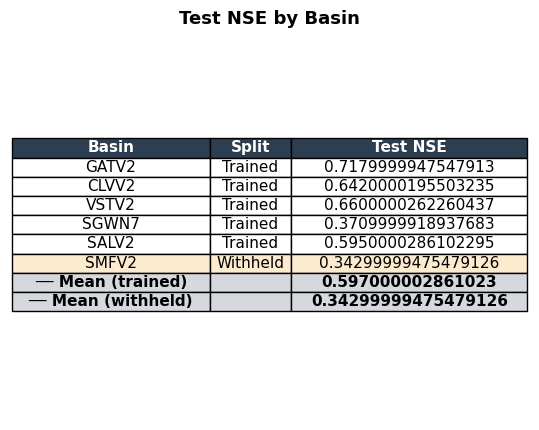

=== Trained Basins ===


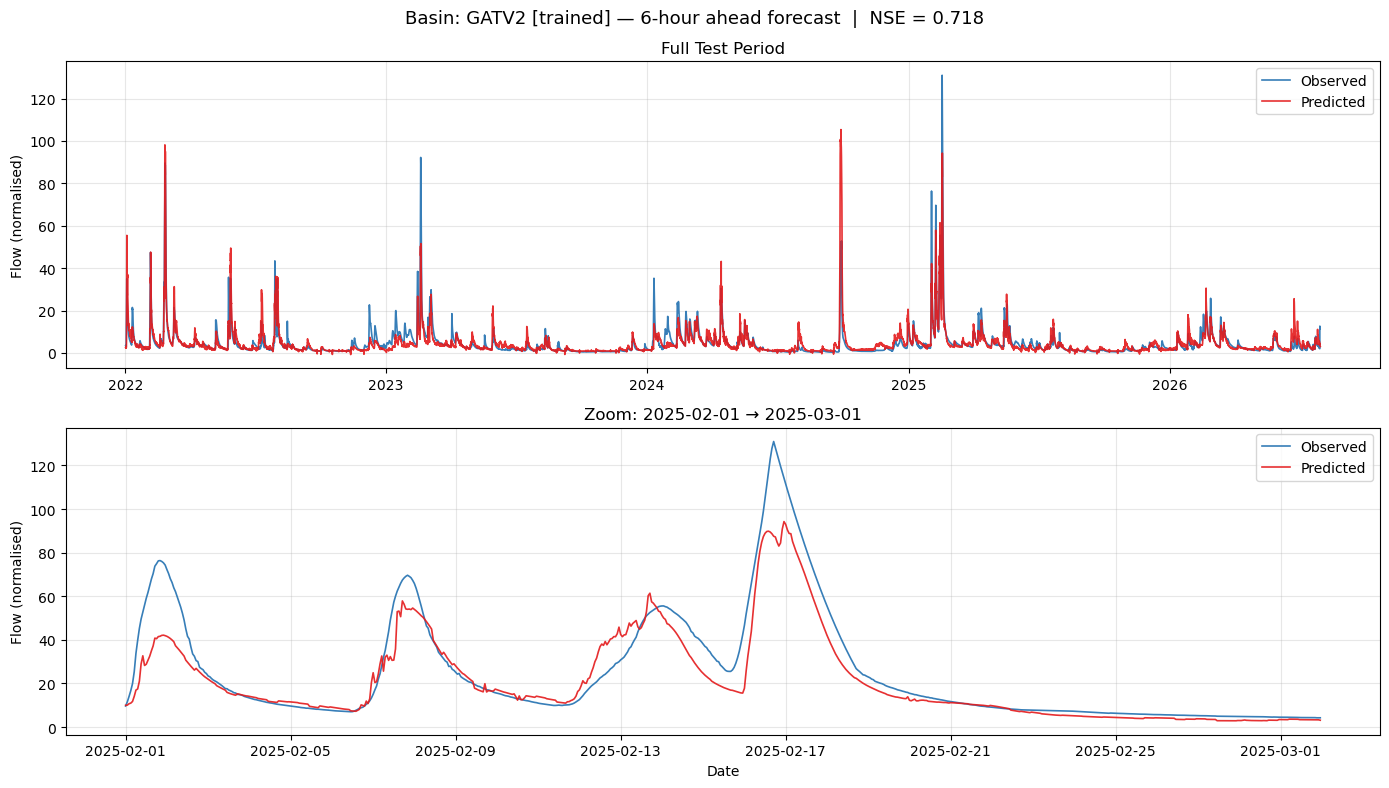

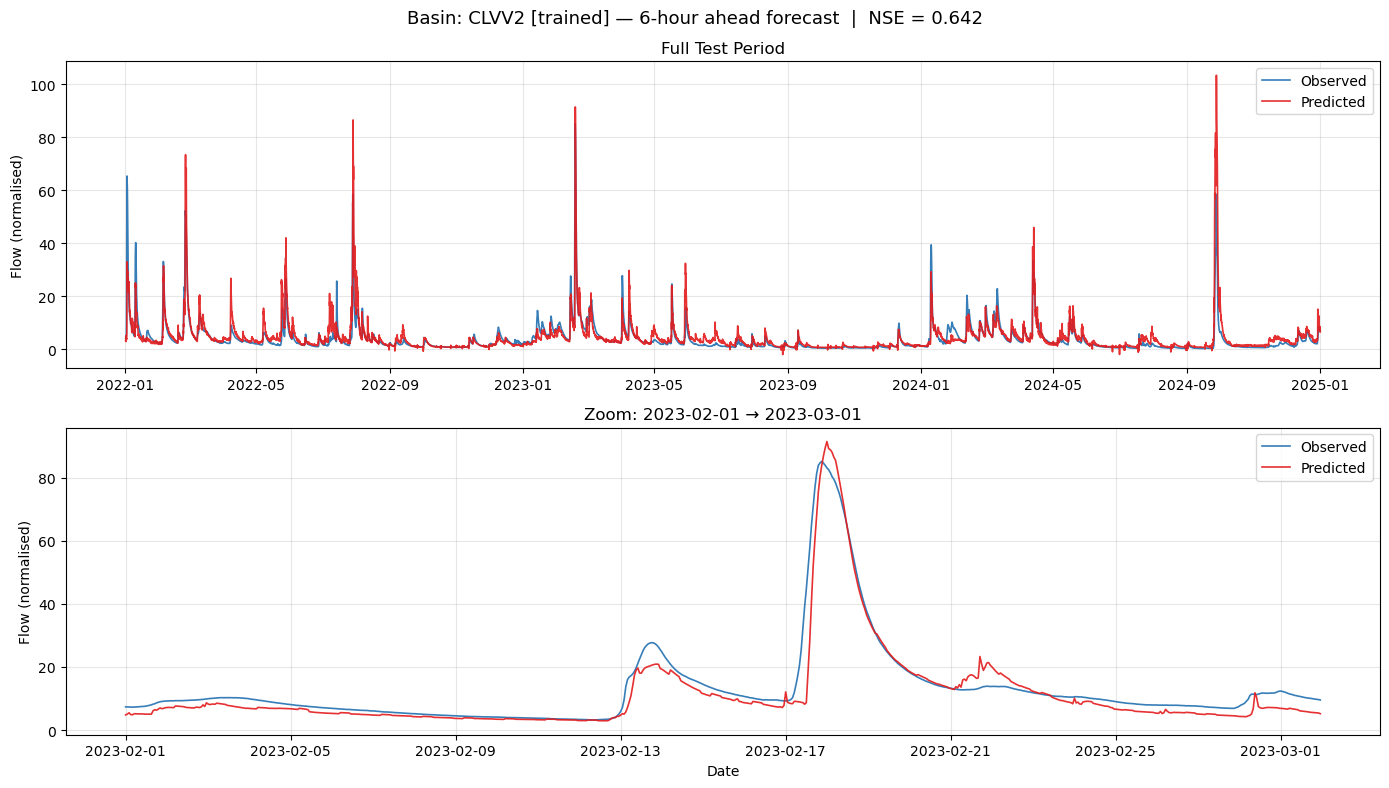

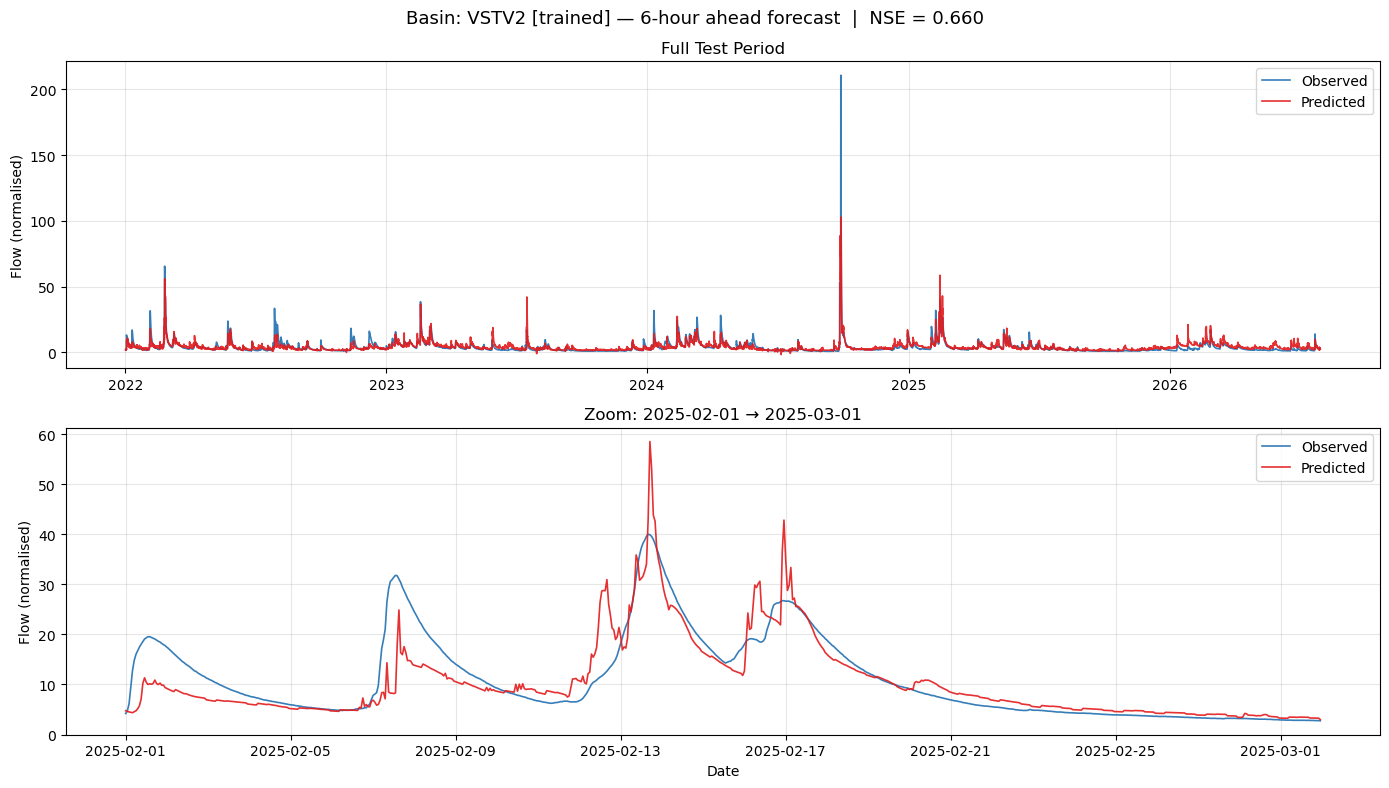

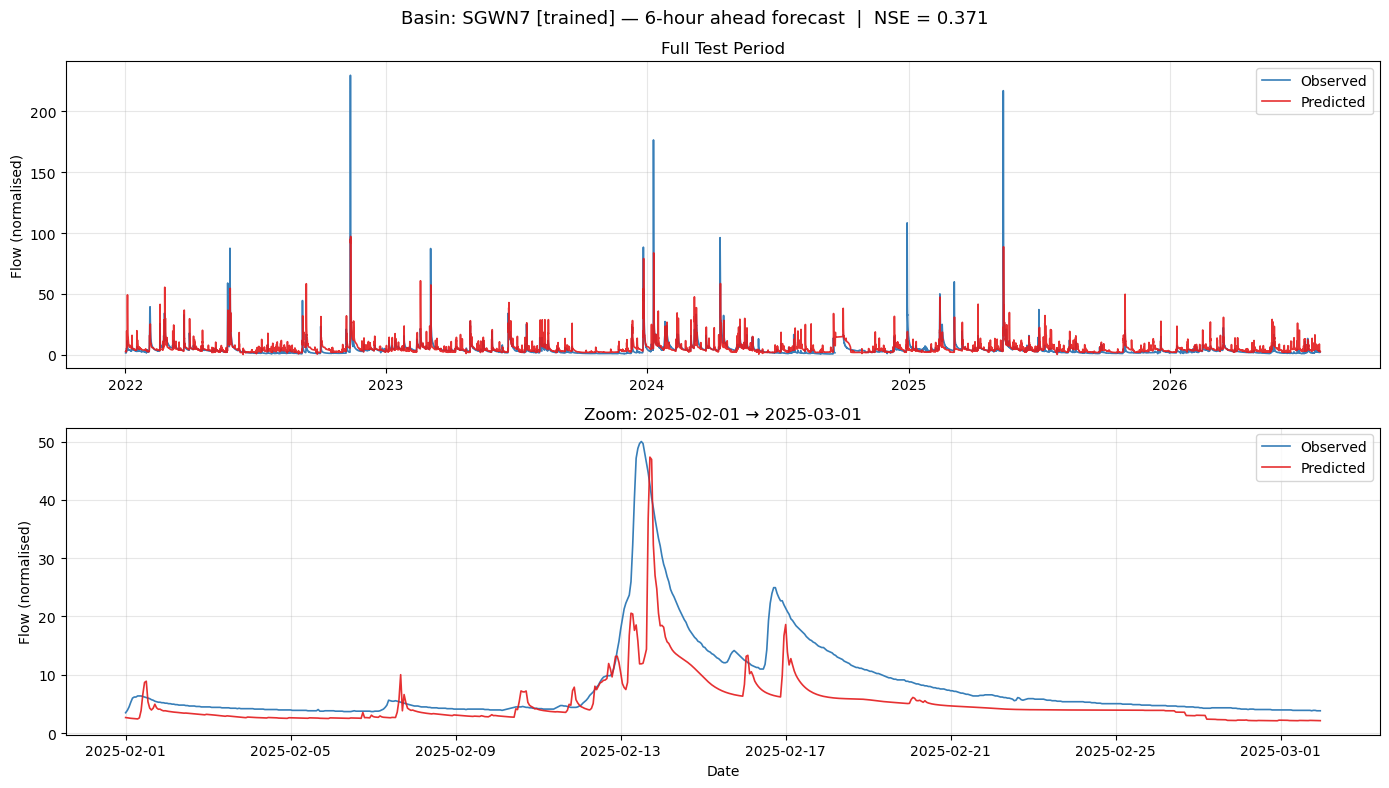

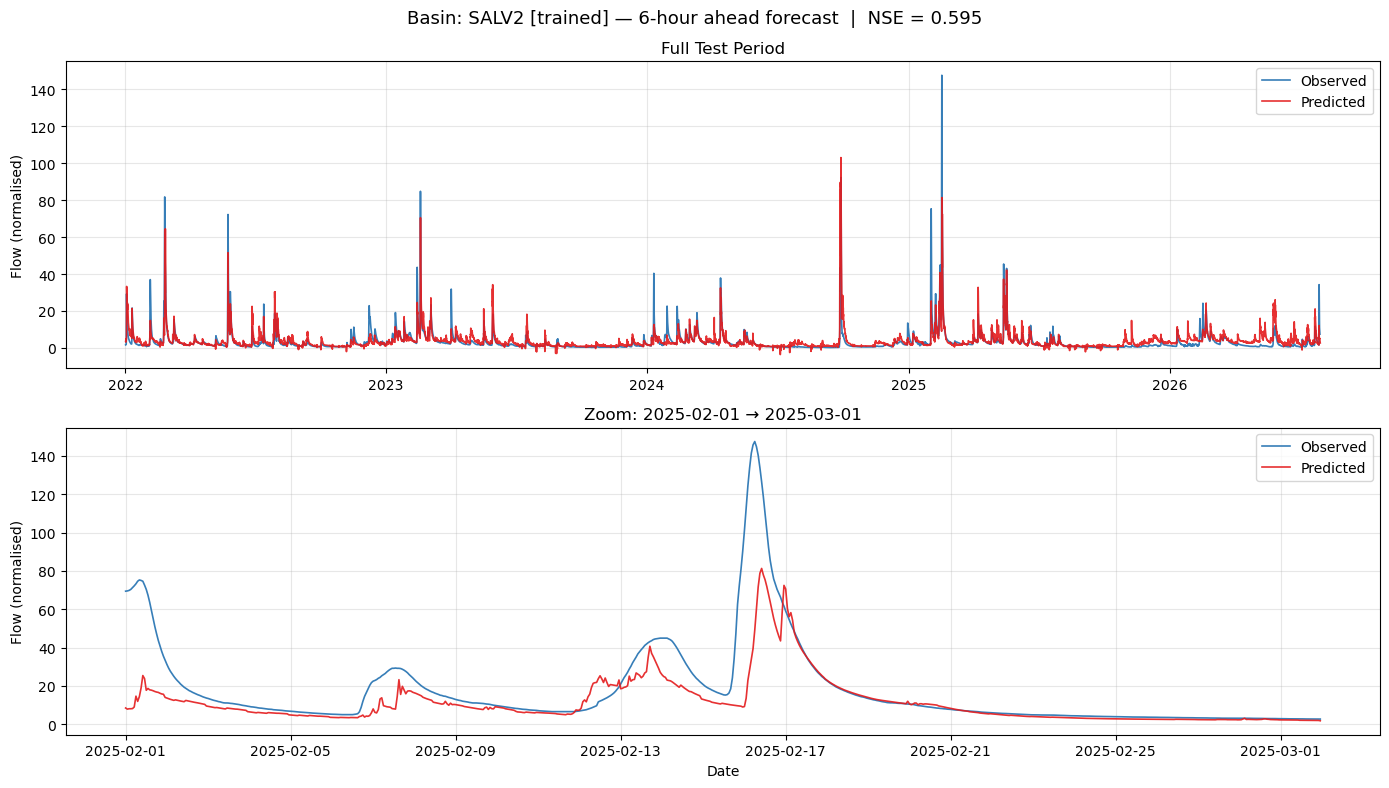


=== Withheld Basin (not seen during training) ===


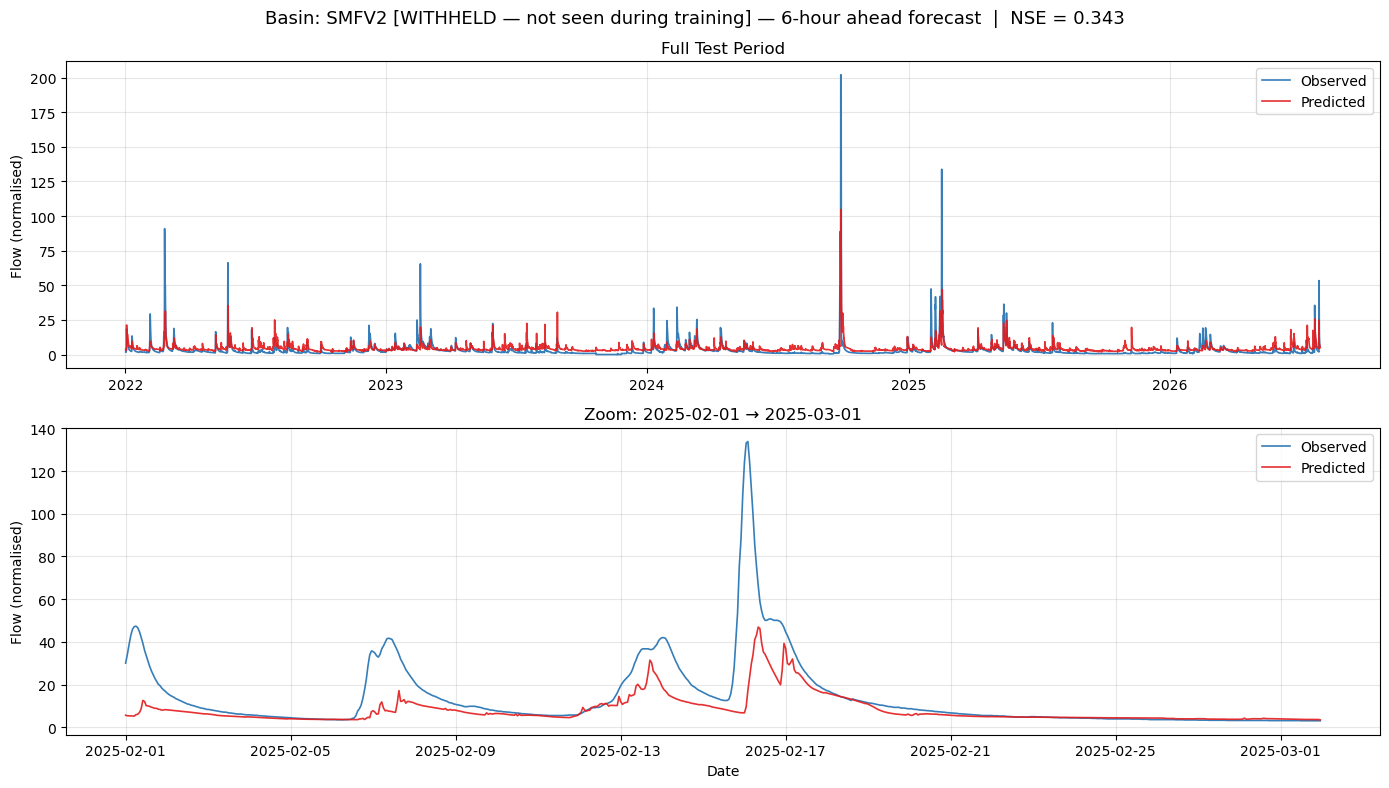

In [57]:
import matplotlib.pyplot as plt

WITHHELD_BASIN = "SMFV2"
zoom_start = "2025-02-01"
zoom_end   = "2025-03-01"

# Per-basin zoom overrides (basin_id: (start, end))
basin_zoom_overrides = {
    "CLVV2": ("2023-02-01", "2023-03-01"),
}

all_basins = df_test["basin"].unique() if "basin" in df_test.columns else ["all"]
trained_basins = [b for b in all_basins if b != WITHHELD_BASIN]
withheld_basins = [b for b in all_basins if b == WITHHELD_BASIN]

# ── NSE summary table as image ─────────────────────────────────────────────────
nse_rows = []
for b in list(trained_basins) + list(withheld_basins):
    nse_rows.append({
        "Basin": b,
        "Split": "Withheld" if b == WITHHELD_BASIN else "Trained",
        "Test NSE": round(per_basin_nse.get(b, float("nan")), 3),
    })
nse_table = pd.DataFrame(nse_rows)

mean_trained  = nse_table[nse_table["Split"] == "Trained"]["Test NSE"].mean()
mean_withheld = nse_table[nse_table["Split"] == "Withheld"]["Test NSE"].mean()

summary_rows = pd.DataFrame([
    {"Basin": "── Mean (trained)",  "Split": "", "Test NSE": round(mean_trained, 3)},
    {"Basin": "── Mean (withheld)", "Split": "", "Test NSE": round(mean_withheld, 3)},
])
display_df = pd.concat([nse_table, summary_rows], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 0.45 * len(display_df) + 0.8))
ax.axis("off")
tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.auto_set_column_width(col=list(range(len(display_df.columns))))

for col in range(len(display_df.columns)):
    tbl[0, col].set_facecolor("#2c3e50")
    tbl[0, col].set_text_props(color="white", fontweight="bold")

for row_idx, row in display_df.iterrows():
    cell_row = row_idx + 1
    if row["Split"] == "Withheld":
        for col in range(len(display_df.columns)):
            tbl[cell_row, col].set_facecolor("#fdebd0")
    elif row["Basin"].startswith("──"):
        for col in range(len(display_df.columns)):
            tbl[cell_row, col].set_facecolor("#d5d8dc")
            tbl[cell_row, col].set_text_props(fontweight="bold")

plt.title("Test NSE by Basin", fontsize=13, fontweight="bold", pad=4)
plt.tight_layout()
plt.show()

def plot_basin(basin_id, label_suffix=""):
    if "basin" in df_test.columns:
        plot_df = df_test[df_test["basin"] == basin_id][["y_obs", "y_sim"]]
    else:
        plot_df = df_test[["y_obs", "y_sim"]]

    plot_df = plot_df.sort_index()
    b_zoom_start, b_zoom_end = basin_zoom_overrides.get(basin_id, (zoom_start, zoom_end))
    zoom_df = plot_df.loc[b_zoom_start:b_zoom_end]
    nse_val = per_basin_nse.get(basin_id, float("nan"))

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    fig.suptitle(
        f"Basin: {basin_id}{label_suffix} — {model_configuration['forecast_horizon']}-hour ahead forecast  |  NSE = {nse_val:.3f}",
        fontsize=13
    )

    axes[0].plot(plot_df.index, plot_df["y_obs"], label="Observed", color="#377eb8", linewidth=1.2)
    axes[0].plot(plot_df.index, plot_df["y_sim"], label="Predicted", color="#e41a1c", linewidth=1.2, alpha=0.9)
    axes[0].set_title("Full Test Period")
    axes[0].set_ylabel("Flow (normalised)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(zoom_df.index, zoom_df["y_obs"], label="Observed", color="#377eb8", linewidth=1.2)
    axes[1].plot(zoom_df.index, zoom_df["y_sim"], label="Predicted", color="#e41a1c", linewidth=1.2, alpha=0.9)
    axes[1].set_title(f"Zoom: {b_zoom_start} → {b_zoom_end}")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Flow (normalised)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("=== Trained Basins ===")
for basin_id in trained_basins:
    plot_basin(basin_id, label_suffix=" [trained]")

print("\n=== Withheld Basin (not seen during training) ===")
for basin_id in withheld_basins:
    plot_basin(basin_id, label_suffix=" [WITHHELD — not seen during training]")

In [ ]:
hydrology_water_balance = {
    runoffcat_aw:      "Area-weighted runoff",
    wetindexcat_aw:    "Wetness index",
    waterinputcat_aw:  "Water input (precip minus evapotranspiration)",
    sw_fluxcat_aw:     "Surface water flux",
}

land_cover_land_use = {
    pctdecidcat_aw:  "Percent Deciduous forest",
    pctconifcat_aw:  "Percent Coniferous forest",
    pctcropcat_aw:   "Percent Cropland",
    pctgrscat_aw:    "Percent Grassland",
    pcturblocat_aw:  "Percent Low-intensity urban",
    pcturbhicat_aw:  "Percent High-intensity urban",
    pctwdwetcat_aw:  "Percent Woody wetland",
    pctowcat_aw:     "Percent Open water",
}

soils_geology = {
    sandcat_aw:   "Percent Sand in soil",
    claycat_aw:   "Percent Clay in soil",
    omcat_aw:     "Percent Organic matter in soil",
    elevcat_aw:   "Mean elevation (m)",
    rockncat_aw:  "Percent Rock outcrop",
}